In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("26-customer_data.csv")

**Scenario**: A retail company wants to analyze the annual income of customers enrolled in its loyalty program and the Spending Score data generated based on the frequency and amount of purchases they make in the store. The goal is to identify customer groups with similar income and spending habits and develop marketing strategies specific to each segment.

In [3]:
data

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889
...,...,...
1494,-4.937560,-10.019685
1495,-7.493203,-5.602109
1496,6.253449,-5.247933
1497,6.684590,-6.017490


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


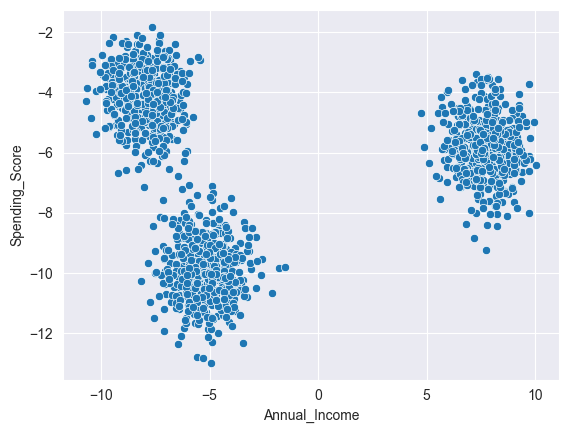

In [5]:
sns.scatterplot(data = data, x="Annual_Income", y="Spending_Score")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test = train_test_split(data, test_size = 0.2, random_state = 15)

In [8]:
X_train

,Annual_Income,Spending_Score
258,7.809992,-5.031123
195,7.769519,-6.059915
817,-8.529586,-4.853877
820,-5.765759,-9.822013
716,-7.932068,-4.882406
...,...,...
667,-6.734875,-5.107626
156,-8.236823,-3.127431
384,-7.744180,-3.563590
645,-6.151325,-9.263209


In [9]:
X_test

,Annual_Income,Spending_Score
513,-5.172436,-11.041683
906,-7.281623,-4.334985
1366,-7.933360,-4.679263
367,7.247201,-4.157474
1392,-5.963997,-9.834777
...,...,...
879,-4.747040,-9.904793
722,-4.886108,-10.754440
557,7.764069,-4.766483
1230,-5.160849,-10.713683


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [18]:
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
#elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [19]:
kmeans.inertia_

4.074405879259844

In [20]:
wcss

[196.9206878471016,
 115.24054081185236,
 11.697030239519936,
 9.89987305995395,
 7.8817005527300195,
 6.08948302740634,
 5.558933254219102,
 5.128717621569291,
 4.396548484592302,
 4.074405879259844]

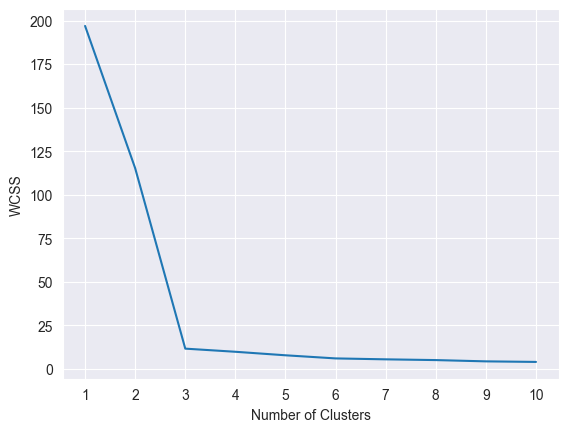

In [22]:
plt.plot(range(1,11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1,11))
plt.show()

In [23]:
kmeans = KMeans(n_clusters=3)

In [24]:
kmeans.fit(X_train_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [25]:
y_pred = kmeans.predict(X_test_scaled)

In [26]:
pd.DataFrame(X_test_scaled, columns=X_test.columns)

,Annual_Income,Spending_Score
0,0.266635,0.173557
1,0.165064,0.774609
2,0.133678,0.743755
3,0.864722,0.790518
4,0.228516,0.281720
...,...,...
295,0.287121,0.275445
296,0.280424,0.199300
297,0.889612,0.735939
298,0.267193,0.202953


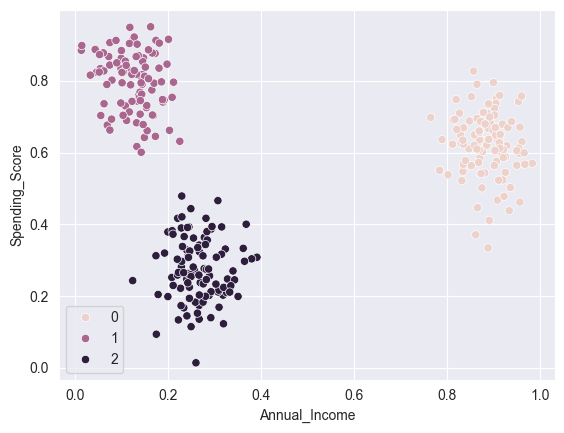

In [27]:
sns.scatterplot(data=pd.DataFrame(X_test_scaled, columns=X_test.columns), x="Annual_Income", y="Spending_Score", hue=y_pred)
plt.show()

In [29]:
# Alternative methods for finding the number of clusters
# pip install kneed

In [30]:
from kneed import KneeLocator

In [31]:
# curve -> concave, convex
# direction -> decreasing, increasing
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')

In [33]:
kl.elbow

np.int64(3)

In [42]:
# Alternative methods for finding the number of clusters 2
# silhoutte score

In [37]:
from sklearn.metrics import silhouette_score

In [39]:
silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_scores.append(score)

In [40]:
silhouette_scores

[0.4808525318845209,
 0.7856941696336582,
 0.6543264512565816,
 0.5110353307041757,
 0.3946986159810209,
 0.3692993760972917,
 0.36472679976776573,
 0.35817681339220986,
 0.3428728791327228]

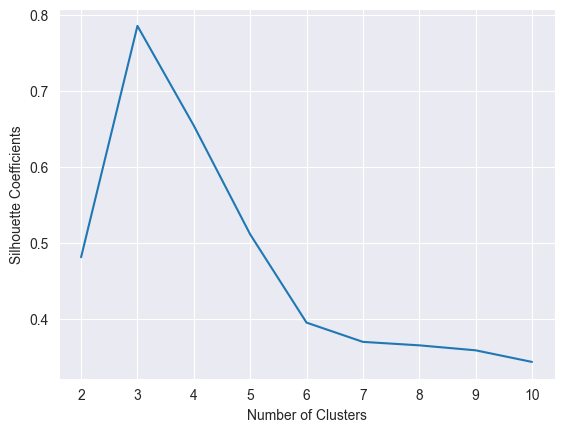

In [41]:
plt.plot(range(2,11), silhouette_scores)
plt.xticks(range(2,11))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Coefficients')
plt.show()